# 05 — Layer Normalization & Residual Connections

Modern Transformers rely on normalization and residual pathways to remain stable as they scale to dozens or even hundreds of layers.  
To understand why these components are essential, we’ll first look at the underlying *instability problems* in deep networks, and then build up to the solutions used in current Transformer architectures.

### What we'll explore

1. **What normalization is (with simple math examples)**  
   - Centering and scaling values  
   - Normalization as a stabilizing mechanism  
   - Learnable scale/shift parameters

2. **Why normalization and residuals are needed**  
   - Instability in deep neural networks  
   - Exploding and vanishing gradients  
   - Why Transformer sublayers can produce activations with wildly varying scales  

3. **How layer normalization works**  
   - Why LN normalizes within each token  
   - Differences from batch normalization  
   - Why LN is a natural fit for Transformers  

4. **Residual connections**  
   - Adding the input back as a stability mechanism  
   - Identity pathways and incremental updates  
   - How residuals allow very deep architectures to train  

5. **Pre-norm vs Post-norm Transformer blocks**  
   - The original post-norm design (Normalize after residual)  
   - The modern pre-norm design (Normalize before sublayer)  
   - Why pre-norm enables stable training at scale  
   - How these choices affect forward activations  

6. **Gradient flow and training stability**  
   - How gradients move through residual pathways  
   - Why post-norm leads to unstable gradients in deep models  
   - How pre-norm preserves identity gradients  
   - (Optional) small visual or numerical experiments

By the end of this section, you’ll understand not just *how* layer normalization and residual connections work, but *why* they are the foundational ingredients that make Transformers stable, efficient, and scalable.

## 1. What Normalization is?

**Normalization** is a technique used in neural networks to keep activations (or features) well-behaved by adjusting their scale and distribution.  
The core idea is simple:

> Make the inputs to each layer more stable and predictable by normalizing them.

This helps the network train faster, avoid instability, and generalize better.

---

## A simple mathematical example

Suppose you have a vector of values:

$ x = [4,\ 6,\ 10,\ 0] $

### Step 1 — Compute the mean  
$ \mu = \frac{4 + 6 + 10 + 0}{4} = 5 $

### Step 2 — Compute the standard deviation  
$ \sigma = \sqrt{\frac{(4-5)^2 + (6-5)^2 + (10-5)^2 + (0-5)^2}{4}}  
= \sqrt{13} \approx 3.605 $

### Step 3 — Normalize (subtract mean, divide by std)

$ \hat{x}_i = \frac{x_i - \mu}{\sigma} $

So we obtain:

$ \hat{x} = \left[  
\frac{4-5}{3.605},\  
\frac{6-5}{3.605},\  
\frac{10-5}{3.605},\  
\frac{0-5}{3.605}  
\right]  
= [-0.28,\ 0.28,\ 1.39,\ -1.39] $

After normalization, the vector has:
- mean $\approx 0$  
- standard deviation $\approx 1$  

This is the essence of **normalization**.

---

## Why normalize?

When inputs have very different scales, neural networks struggle to learn stable weights.  
Normalization helps by ensuring:

- more stable gradients  
- smoother learning  
- faster convergence  

This principle holds outside deep learning too — e.g., classical ML models often normalize features so each dimension contributes similarly.

---

### Adding flexibility: scale and shift

To make normalization more expressive, we introduce two learned parameters:

$ y_i = \gamma \hat{x}_i + \beta $

- $\gamma$ (gamma) rescales the normalized value  
- $\beta$ (beta) shifts it  

This lets the network learn any distribution it needs while retaining the stability benefits of normalization.

---

Normalization is a fundamental building block of modern deep learning, and Transformers use a specific version — **Layer Normalization** — to remain stable even at great depth.

## 2. Why normalization and residuals are needed

Deep neural networks are powerful, but they come with an inherent challenge:  
as information flows through many layers, the *scale* and *distribution* of activations can drift, amplify, or collapse.  
Transformers, with their stacked attention and MLP blocks, are especially vulnerable to this.

### Instability in deep networks
Each layer transforms its inputs into new representations.  
As we stack more layers, these transformations compound. Without safeguards, the network can enter unstable regimes where:
- activations grow without bound,
- or shrink toward zero,
- or vary unpredictably from layer to layer.

This instability makes optimization difficult — gradients have trouble finding a smooth path through the network.

### Exploding and vanishing gradients
During backpropagation, gradients must flow from the output all the way back to early layers.  
If activations in the forward pass become too large or too small, the gradients inherit this instability:

- **Exploding gradients** cause weight updates that are too large, destabilizing training.  
- **Vanishing gradients** cause early layers to learn extremely slowly or stop learning entirely.

Both issues become exponentially worse as networks get deeper.

### Why Transformer sublayers can produce wildly scaled activations
Transformer blocks contain two powerful components:
- **Multi-Head Attention**, which mixes information across all tokens,
- **Feed-Forward Networks**, which apply large linear projections and nonlinearities.

Both can easily output activations with highly variable magnitudes:
- Attention can create sharp, high-gain focus on specific tokens.  
- MLPs can amplify or shrink values depending on initialization and nonlinearity.  

Without mechanisms to control the scale of these activations, each layer’s output becomes unpredictable. This unpredictability propagates through the depth of the model, severely hurting training stability.

---

Normalization and residual connections were introduced to solve these problems by:
- keeping activations at reasonable scales,
- preserving gradient flow,
- and enabling Transformer architectures to scale to hundreds of layers.

## Example: Why Normalization Stabilizes Deep Networks

To make the effect of normalization concrete, we can run a simple experiment.  
We create a batch of fake token embeddings and repeatedly pass them through a stack of linear layers — similar to the transformations that occur inside Transformer blocks.

We compare two scenarios:

1. **Without normalization**  
   Each layer receives whatever activations the previous layer produced.  
   If these activations grow or shrink in magnitude, the effect compounds as depth increases.

2. **With LayerNorm**  
   Before each linear layer, we apply Layer Normalization.  
   This forces the activations for each token to have a stable mean and variance, preventing the scale from drifting.

In the code cell below:

- `run_stack(..., use_norm=False)` builds a deep stack *without* normalization  
- `run_stack(..., use_norm=True)` applies LayerNorm before each linear transform  
- We track the **standard deviation** of the activations after each layer  
- Then we plot how the activation scale evolves with depth

### What we expect

- **Without normalization:** the activation scale will drift — sometimes exploding, sometimes collapsing — depending on initialization.  
  This mirrors what happens in deep networks where gradients become unstable.

- **With LayerNorm:** the activation scale stays near 1.0 across the entire stack, even for many layers.  
  This demonstrates how normalization keeps signals well-behaved and prevents instability.

### Understanding the Effect of Normalization (What This Plot Shows)

This simple experiment mirrors a key challenge in Transformers:  
**deep stacks of attention and MLP layers can become unstable unless their activations are normalized.**  
LayerNorm provides a stabilizing effect that allows Transformers to scale to great depth.

The chart below compares what happens when we repeatedly apply linear transformations to token embeddings **with** and **without** normalization.  
Even though this is a simplified setup, it reveals the exact stability problems that occur in deep neural networks — and why Transformers need LayerNorm.

### No Normalization: The Signal Collapses

The blue line shows the **standard deviation of the activations** after each layer when no normalization is used.

What we see:

- The activation scale drops rapidly layer after layer.  
- By around layer 10, the activations have nearly flattened to a tiny range.  
- The network is effectively **destroying** the input signal as depth increases.

#### In real terms:
- Early layers would stop learning (vanishing gradients).  
- Information from the input cannot survive deep into the model.  
- The network becomes unstable and extremely hard to train.  
- Small differences in the input are erased — the model becomes “blind” to important structure.

This is exactly what happens in real deep networks without normalization:  
**depth causes the signal to collapse (or explode), breaking training.**

### With LayerNorm: Stability Across Depth

The orange line shows the activation scale when we apply **LayerNorm before each layer**.

What we see:

- The activation scale stays near ~0.6 across all 30 layers.  
- There is no collapse, no explosion, just small fluctuations.  
- Each layer gets a stable, well-behaved input.

#### In real terms:
- Every layer starts from a consistent baseline (mean 0, variance 1).  
- The network can keep stacking layers without losing information.  
- Gradients stay healthy → deep learning works.  
- The model becomes trainable even at extreme depths (50, 100, 200 layers).  
- Each layer “edits” the representation rather than distorting it.

This is why nearly all modern Transformers use **LayerNorm** (usually in the Pre-Norm style).

---

### The takeaway

> **Normalization prevents deep networks from drifting into unstable regimes.  
Without it, information collapses or explodes as it moves through the layers.  
With it, every layer starts with stable inputs, allowing deep architectures to learn effectively.**

This toy example captures one of the key design insights behind Transformers —  
**depth is only useful if the network stays stable**, and normalization is what makes that possible.

> **Implementation note:** In the code below, the same `LayerNorm` instance is reused across layers.  
> Real Transformer blocks each have *their own* LayerNorm parameters, but reusing one instance here keeps the demo simple without changing the qualitative behavior.

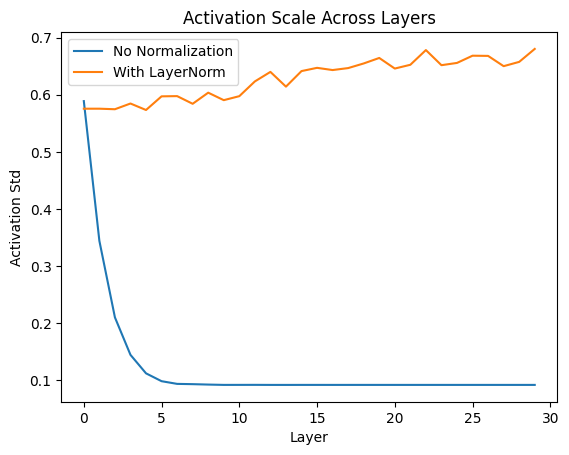

In [22]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

# --------------------------------------------------------
# Create fake token embeddings
# --------------------------------------------------------
batch_size = 4
seq_len = 6
hidden_dim = 64

x = torch.randn(batch_size, seq_len, hidden_dim)

# A simple linear layer to simulate part of a Transformer sublayer
layer = nn.Linear(hidden_dim, hidden_dim)

# Same layer but with LayerNorm
layernorm = nn.LayerNorm(hidden_dim)

# --------------------------------------------------------
# Run a stack of layers, with or without LayerNorm
# --------------------------------------------------------
def run_stack(x, layers=20, use_norm=False):
    activations = []
    out = x.clone()

    for i in range(layers):
        if use_norm:
            out = layernorm(out)        # normalize before layer
        out = layer(out)                # linear transform
        activations.append(out.std().item())  # track activation scale

    return activations

# Run both variants
no_norm_stats = run_stack(x, layers=30, use_norm=False)
ln_stats = run_stack(x, layers=30, use_norm=True)

# --------------------------------------------------------
# Plot activation scales across layers
# --------------------------------------------------------
plt.plot(no_norm_stats, label="No Normalization")
plt.plot(ln_stats, label="With LayerNorm")
plt.xlabel("Layer")
plt.ylabel("Activation Std")
plt.title("Activation Scale Across Layers")
plt.legend()
plt.show()

## 3. How Layer Normalization Works

> **Note:** Unlike BatchNorm, LayerNorm does *not* attempt to stabilize the distribution across samples or across the batch.  
> LN normalizes **within each token embedding**, so it stabilizes *per-token* feature statistics but does not enforce any global feature distribution regularization. This distinction is important because it makes LN behave predictably even when batch size or sequence length varies.

Layer Normalization (LN) is a normalization technique designed for architectures where sequence length and batch size can vary — which makes it a natural fit for Transformers.  
LN stabilizes the activations **within each token**, ensuring that every token embedding has a predictable scale before it enters a sublayer (attention or MLP).

---

### Why LayerNorm normalizes *within each token*

Given a token embedding:

$ x = [x_1, x_2, \dots, x_H] $

LayerNorm computes:

- the mean across the **hidden dimension**  
  $ \mu = \frac{1}{H} \sum_{i=1}^H x_i $

- the variance across the **hidden dimension**  
  $ \sigma^2 = \frac{1}{H} \sum_{i=1}^H (x_i - \mu)^2 $

Then normalizes each feature:

$ \hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}} $

This normalization happens **independently for each token**, so the scaling of one token never affects another.

#### Why normalize this way?

- Each token gets its own stable, well-scaled representation.  
- LN does not depend on how many tokens are in the sequence.  
- LN behaves the same whether we're processing 512 tokens or just 1 (as in autoregressive decoding).  
- Every sublayer receives inputs with predictable statistics, improving stability as depth increases.

---

### How LayerNorm differs from BatchNorm

| Feature | **BatchNorm** | **LayerNorm** |
|--------|----------------|---------------|
| Normalizes over | Batch dimension (across samples) | Hidden dimension (within each token) |
| Depends on batch size? | Yes | No |
| Stable for variable sequence lengths? | No | Yes |
| Works when batch = 1? | Often unstable | Perfect |
| Uses running statistics? | Yes | No |

BatchNorm was designed mainly for CNNs, where inputs have a fixed shape and large batch sizes are common.  
Transformers, however, require something that:

- works with very small batches  
- works with changing sequence lengths  
- works during generation (processing one token at a time)  
- does not mix information between tokens

LayerNorm satisfies all of these requirements.

---

### Why LayerNorm is a natural fit for Transformers

1. **Consistent scaling per token**  
   Attention operations are sensitive to input magnitude. LN ensures every token enters with controlled variance.

2. **Independent of batch shape**  
   LN works no matter how many tokens or sequences are present.

3. **Works in autoregressive decoding**  
   When generating text one token at a time, LN behaves identically — BatchNorm does not.

4. **Stabilizes gradient flow**  
   LN smooths the forward pass, which directly improves gradient stability in deep networks.

5. **Respects the structure of Transformers**  
   Transformers treat each token embedding as a vector. LN normalizes *within* that vector, not across tokens.

---

## Visualizing the Difference

Below is a plot showing how the activation scale changes across 30 layers when we repeatedly apply a linear transformation in three scenarios:

- **No normalization**  
- **LayerNorm applied before each layer**  
- **BatchNorm applied before each layer**

This mirrors what happens inside deep Transformers, but with a simplified setup.

---

### What the visual shows

- **No Normalization (blue):**  
  Activations collapse toward zero as depth increases. This represents *vanishing activations* → leads to *vanishing gradients* → early layers cannot learn.

- **BatchNorm (green):**  
  Activation scale is more stable than no normalization, but still drifts because BatchNorm mixes information across samples and depends on batch statistics.  
  In real Transformers, BN would behave unpredictably with varying sequence lengths or batch = 1.

- **LayerNorm (orange):**  
  Activation scale remains stable across all layers.  
  This is exactly why LN enables Transformers to grow deeper without instability.

LN ensures every layer sees well-scaled, predictable inputs — and the visual demonstrates this effect clearly.

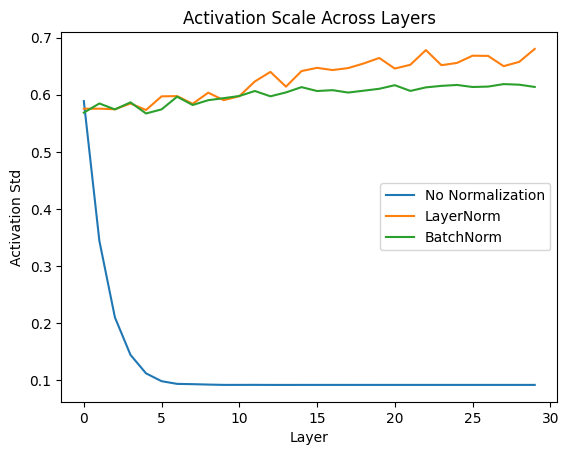

In [23]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

# --------------------------------------------------------
# Create fake token embeddings
# --------------------------------------------------------
batch_size = 4
seq_len = 6
hidden_dim = 64

x = torch.randn(batch_size, seq_len, hidden_dim)

# A simple linear layer to simulate part of a Transformer sublayer
layer = nn.Linear(hidden_dim, hidden_dim)

# Normalization layers
layernorm = nn.LayerNorm(hidden_dim)
batchnorm = nn.BatchNorm1d(hidden_dim)  # BN normalizes over batch dimension

# --------------------------------------------------------
# Run a stack of layers with optional normalization
# --------------------------------------------------------
def run_stack(x, layers=20, mode="none"):
    activations = []
    out = x.clone()

    for i in range(layers):
        if mode == "layernorm":
            out = layernorm(out)        # LN: normalize within each token

        elif mode == "batchnorm":
            # reshape to (batch*seq, hidden) for BatchNorm
            b, s, h = out.shape
            out_bn = out.reshape(b * s, h)
            out_bn = batchnorm(out_bn)  # BN: normalize across batch dimension
            out = out_bn.reshape(b, s, h)

        # linear transform
        out = layer(out)

        # track the scale of activations at this depth
        activations.append(out.std().item())

    return activations

# Run all variants
no_norm_stats = run_stack(x, layers=30, mode="none")
ln_stats = run_stack(x, layers=30, mode="layernorm")
bn_stats = run_stack(x, layers=30, mode="batchnorm")

# --------------------------------------------------------
# Plot activation scales across layers
# --------------------------------------------------------
plt.plot(no_norm_stats, label="No Normalization")
plt.plot(ln_stats, label="LayerNorm")
plt.plot(bn_stats, label="BatchNorm")
plt.xlabel("Layer")
plt.ylabel("Activation Std")
plt.title("Activation Scale Across Layers")
plt.legend()
plt.show()

## 4. Residual Connections

Residual connections are one of the most important architectural ideas in deep learning.  
They were introduced to solve a fundamental problem:  
**as networks get deeper, it becomes harder for them to pass information forward and gradients backward.**

Transformers rely heavily on residual connections for stability and trainability.

---

### What a residual connection does

Normally, a layer computes:

$y = F(x)$

A residual layer instead computes:

$y = x + F(x)$

This means each layer doesn’t have to *rebuild* the entire representation — it only needs to make a **small update** to what’s already there.

---

### Identity pathways (the "gradient highway")

Because the input is added back unchanged, the gradients during backpropagation always have a **direct identity path**:

$\frac{\partial y}{\partial x} = 1 + \frac{\partial F}{\partial x}$

The key term is the `1`.  
Even if $\frac{\partial F}{\partial x}$ becomes tiny or unstable, the gradient can still flow through the network.

This prevents the **vanishing gradient** problem that plagues deep architectures.

---

### Analogy — Like Version Control for Neural Networks

Think of each layer in a deep network as committing changes to a project.

- **Without residuals:**  
  Every contributor deletes the entire codebase and rewrites it from scratch for each commit.  
  Most of the useful work is lost, bugs creep in, and the project becomes unstable very quickly.

- **With residuals:**  
  Each contributor starts from the previous version and adds a **small, incremental update**.  
  The core structure is preserved, improvements accumulate safely, and the project grows in a controlled way.

Residual connections work the same way:  
the network keeps the previous representation (`x`) and each layer adds a small update (`F(x)`), just like committing incremental changes rather than rewriting everything.

---

## Forward Pass Visualization (Activation Stability)

The first plot shows how activations behave as we repeatedly apply linear layers:

- **No Residual (blue):**  
  Activations collapse toward zero. The network “forgets” information as depth increases.

- **With Residual (orange):**  
  Activations explode exponentially — each layer adds more on top of what came before.

This reveals something important:  
**Residuals help gradients but can destabilize activations** unless combined with normalization.

This is why real Transformer blocks include **LayerNorm around the residual path**.

> Modern Transformer variants also incorporate residual scaling (e.g., multiplying the residual branch by \(1/\sqrt{2}\)) or use learnable RMSNorm gain factors. These mechanisms help control the cumulative variance growth caused by repeatedly adding residual updates, especially in very deep models (e.g., DeepNorm, GPT-NeoX).

---

## Backward Pass Visualization (Gradient Flow)

The second plot shows average gradient magnitude per layer:

- **No Residual:**  
  Gradients become almost zero for early layers.  
  The model cannot learn effectively — classic *vanishing gradient* problem.

- **With Residual:**  
  Gradients remain stable across the entire depth.  
  Every layer receives a strong learning signal.

This shows why residual connections enable deep models like Transformers to train at all.

---

## Why Transformers Need Residuals

Residual connections:

- provide an **identity shortcut** that protects gradient flow  
- reduce the burden on each layer — they only make small corrections  
- prevent deep networks from collapsing during training  
- allow models with 48, 96, or even 120+ layers to learn effectively  

However, because residuals can cause **activation explosion** (as the first plot shows),  
Transformers always pair them with LayerNorm (usually in the **pre-norm** configuration).

Residuals + LayerNorm form the stable backbone of the entire Transformer architecture.

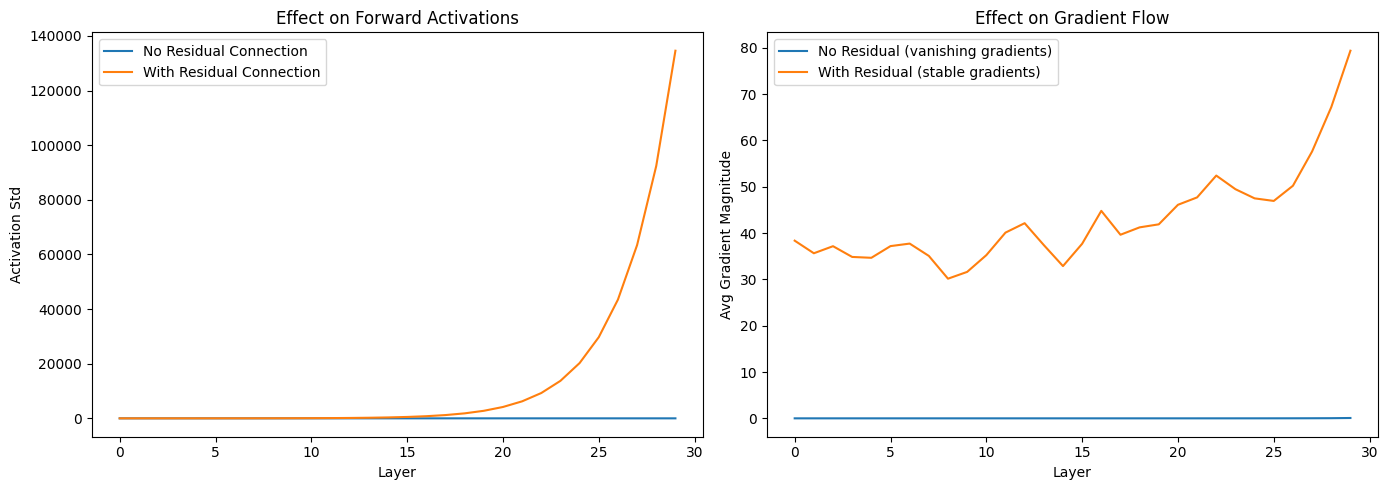

In [24]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

# =========================================================
# Part 1 — Forward Activations: Residual vs No Residual
# =========================================================

batch, seq, hidden = 4, 6, 64
x = torch.randn(batch, seq, hidden)

layer = nn.Linear(hidden, hidden)

def run_stack(x, layers=30, use_residual=False):
    activations = []
    out = x.clone()

    for _ in range(layers):
        f = layer(out)                        # F(x)
        out = out + f if use_residual else f  # add residual or not
        activations.append(out.std().item())  # record activation scale
    return activations

no_resid = run_stack(x, use_residual=False)
with_resid = run_stack(x, use_residual=True)

# =========================================================
# Part 2 — Backward Gradients: Residual vs No Residual
# =========================================================

class DeepNet(nn.Module):
    def __init__(self, depth=30, hidden=64, residual=False):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(hidden, hidden) for _ in range(depth)])
        self.residual = residual
    
    def forward(self, x):
        for layer in self.layers:
            out = layer(x)
            x = x + out if self.residual else out
        return x

def measure_gradients(residual=False):
    model = DeepNet(depth=30, hidden=64, residual=residual)
    x = torch.randn(1, 64)
    out = model(x)
    loss = out.sum()
    loss.backward()

    grads = [layer.weight.grad.abs().mean().item() for layer in model.layers]
    return grads

grads_no_resid = measure_gradients(residual=False)
grads_resid = measure_gradients(residual=True)

# =========================================================
# Side-by-side plots
# =========================================================

plt.figure(figsize=(14, 5))

# ---- Left plot: Activation Scale ----
plt.subplot(1, 2, 1)
plt.plot(no_resid, label="No Residual Connection")
plt.plot(with_resid, label="With Residual Connection")
plt.xlabel("Layer")
plt.ylabel("Activation Std")
plt.title("Effect on Forward Activations")
plt.legend()

# ---- Right plot: Gradient Magnitudes ----
plt.subplot(1, 2, 2)
plt.plot(grads_no_resid, label="No Residual (vanishing gradients)")
plt.plot(grads_resid, label="With Residual (stable gradients)")
plt.xlabel("Layer")
plt.ylabel("Avg Gradient Magnitude")
plt.title("Effect on Gradient Flow")
plt.legend()

plt.tight_layout()
plt.show()

# 5. Pre-Norm vs Post-Norm Transformer Blocks

Layer Normalization can be placed in two different positions inside a Transformer block:  
**before** the sublayer (pre-norm) or **after** the residual addition (post-norm).  
This choice dramatically affects **activation stability**, **gradient flow**, and the ability to train **deep** Transformer models.

A helpful analogy:

> **Think of gradients as water flowing through pipes.**  
> Pre-Norm uses a *straight, wide main pipe* (an identity path) that guarantees water always flows.  
> Post-Norm puts a *water filter* (LayerNorm) **after** every junction — and stacking many filters in a row eventually chokes the flow.

We compare:

- the original **post-norm** design from the 2017 Transformer  
- the modern **pre-norm** design used in GPT, LLaMA, PaLM, T5, and virtually all LLMs today

---

# Post-Norm (original Transformer)

**Formula:**  
$y = \mathrm{LayerNorm}(x + F(x))$

Where:  
- $x$ is the block input  
- $F(x)$ is attention or feed-forward output  

### Why Post-Norm is problematic

- The residual branch is **not** an identity — gradients must pass *through* LayerNorm.  
- LayerNorm **rescales** and **mixes** gradient vectors.  
- Repeating this across many layers causes gradients to shrink **rapidly**.  
- Deep models (24+ layers) become fragile, unstable, or require special tricks.

### What the plot shows for Post-Norm

**Activation std:**  
- Perfectly flat at **1.0**.  
- This happens because LN forces each block output to have variance 1, even if the underlying computation is unstable.

**Gradients:**  
- Gradients collapse to roughly $10^{-7}$.  
- Like stacking many water filters, each LN reduces the signal slightly; after 48 layers the flow is nearly gone.

> **Why gradients collapse mathematically:**  
> LayerNorm’s Jacobian projects gradients onto a subspace orthogonal to the vector of ones and scales them by the inverse standard deviation. This means all singular values of the Jacobian are **< 1**, so repeatedly applying LN causes an exponential decay in gradient magnitude. In post-norm architectures, gradients must pass through dozens of these Jacobians in sequence, which leads to severe gradient collapse.

---

# Pre-Norm (modern GPT/LLaMA style)

**Formula:**  
$y = x + F(\mathrm{LayerNorm}(x))$

### Why Pre-Norm works dramatically better

- The residual branch is a **clean identity**:  
  $\frac{\partial y}{\partial x} = 1 + \text{(small correction)}$
- The identity path guarantees strong gradient flow (the “wide pipe”).  
- Each sublayer receives normalized inputs → stable computations.  
- Deep models (48, 96, 200+ layers) train reliably without special tricks.

### What the plot shows for Pre-Norm

**Activation std:**  
- Gradually increases with depth.  
- Because LN is *before* the sublayer and nothing normalizes the residual sum afterward,  
  $x + F(\mathrm{LN}(x))$  
  accumulates variance across layers.

**Gradients:**  
- Stay in the healthy range $10^{-1} \rightarrow 10^{-2}$.  
- This is **6–7 orders of magnitude larger** than Post-Norm.  
- The identity skip connection preserves gradient strength across depth.

---

# What the Experiment Measured

For each layer in a 48-layer stack, we measured:

1. **Activation standard deviation** after each block  
2. **Gradient norm** $\|\partial L / \partial x_l\|$ flowing into each block  

These correspond directly to the two plots.

---

# Diagram of the Difference

### Post-Norm (gradient bottleneck)

x → F(x) → x + F(x) → LN → y
↑
gradient squeezed by LN

### Pre-Norm (clean gradient path)

x → LN → F → x + F → y
↑
gradient flows directly through identity

---

# Summary

| Aspect | Post-Norm | Pre-Norm |
|--------|-----------|----------|
| Residual gradient path | Distorted by LN | Clean identity |
| Activation behavior | Locked to std = 1 | Gradual drift (expected) |
| Gradient flow | Collapses (~$10^{-7}$) | Strong & stable ($10^{-1} \rightarrow 10^{-2}$) |
| Scalability | Poor beyond ~24 layers | Excellent (hundreds of layers) |
| Used in | Original Transformer | All modern LLMs |

**In short:**  
Pre-Norm preserves a reliable gradient “highway,” while Post-Norm repeatedly squeezes the gradient signal through LayerNorm.  
This architectural shift is one of the core reasons modern Transformers can scale to massive depths and sizes.

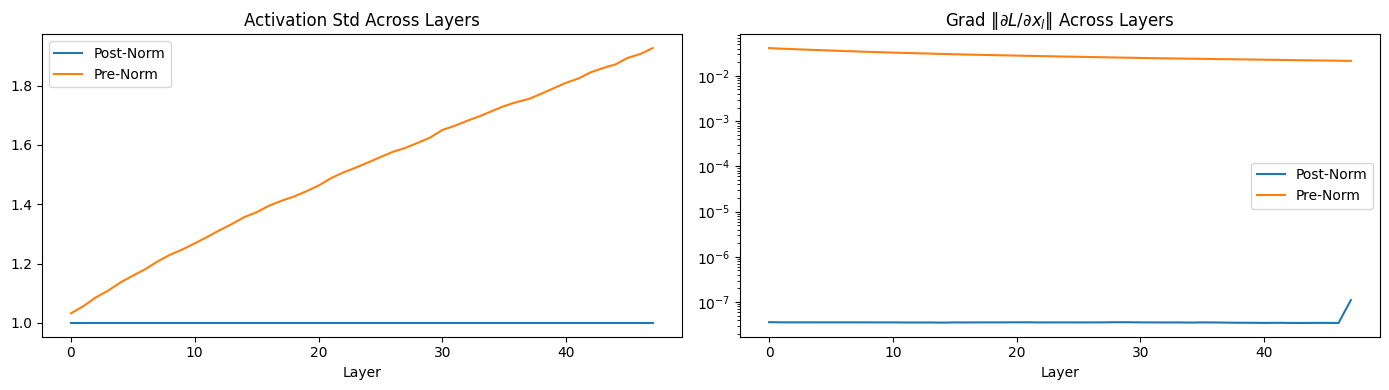

In [25]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

# --- your PostNormBlock and PreNormBlock definitions here ---
# (use the ones you already have with attention + FFN)

class BlockStack(nn.Module):
    def __init__(self, block_class, depth=24, hidden_dim=512):
        super().__init__()
        self.blocks = nn.ModuleList([block_class(hidden_dim) for _ in range(depth)])

    def forward_with_intermediates(self, x):
        """
        Returns:
          out: final output
          xs: list of activations BEFORE each block (for gradient measurement)
          act_stds: std of output after each block
        """
        xs = []
        act_stds = []
        for block in self.blocks:
            x.retain_grad()          # tell PyTorch to keep grad for this tensor
            xs.append(x)
            x = block(x)
            act_stds.append(x.std().item())
        return x, xs, act_stds


def run_stack(model):
    batch_size, seq_len, hidden_dim = 4, 16, 512
    x = torch.randn(batch_size, seq_len, hidden_dim, requires_grad=True)

    out, xs, act_stds = model.forward_with_intermediates(x)
    loss = out.pow(2).mean()
    loss.backward()

    state_grad_norms = [t.grad.norm().item() for t in xs]
    return act_stds, state_grad_norms


depth = 48
hidden_dim = 512

post_model = BlockStack(PostNormBlock, depth=depth, hidden_dim=hidden_dim)
pre_model  = BlockStack(PreNormBlock,  depth=depth, hidden_dim=hidden_dim)

post_acts, post_state_grads = run_stack(post_model)
pre_acts,  pre_state_grads  = run_stack(pre_model)

# --- Plot ---

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Activation std
axes[0].plot(post_acts, label="Post-Norm")
axes[0].plot(pre_acts,  label="Pre-Norm")
axes[0].set_title("Activation Std Across Layers")
axes[0].set_xlabel("Layer")
axes[0].legend()

# Gradient of hidden state (log scale to see both)
axes[1].plot(post_state_grads, label="Post-Norm")
axes[1].plot(pre_state_grads,  label="Pre-Norm")
axes[1].set_title("Grad $\|\partial L / \partial x_l\|$ Across Layers")
axes[1].set_xlabel("Layer")
axes[1].set_yscale("log")  # important: visualize huge scale differences
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Gradient Flow and Training Stability

Residual connections are supposed to act like *gradient highways*:  
even if the internal transformation is messy, the gradient can still travel backward through the identity path.

But whether this “highway” actually works depends on where LayerNorm is placed.

---

## Visual Analogy: Water Flow Through Pipes

Think of gradients as **water** trying to flow backward through a long series of pipes:

### **Pre-Norm = wide, straight main pipe**

[ x ] → (LN → F) → + → [ y ]
↑
identity pipe → gradient flows freely

Gradients always have a clean route (the identity path) that passes through **untouched**.

### **Post-Norm = filter placed after every pipe**

[ x ] → (F) → + → LN → [ y ]
↑
gradient squeezed through LN

LayerNorm acts like a **water filter**.  
One filter is fine. Forty-eight filters in a row? Almost no water gets through.

---

## What This Looks Like in Practice

Below is a small numerical experiment that:

1. Stacks 48 Transformer-style layers  
2. Measures the gradient magnitude at each layer  
3. Compares **Pre-Norm** vs **Post-Norm**

### What you see:

- **Post-Norm**:  
  Gradient magnitudes fall off a cliff → near-zero after a few layers

> **Why there is a small spike at the final Post-Norm layer:**  
> In the visualization, you may notice that the Post-Norm gradient curve has a small upward bump at the very last layer. This is expected.  
> Because the final LayerNorm sits *directly before the loss*, its gradient only passes through a single LN Jacobian, while earlier layers pass through many stacked LN operations that aggressively shrink gradients. The last layer therefore receives a slightly stronger signal. The spike is small in absolute magnitude (still around 10⁻⁶), but it appears noticeable on a log scale. This effect is normal and does not change the overall conclusion: Post-Norm collapses gradient flow across depth.

- **Pre-Norm**:  
  Gradients stay strong → identity path keeps them alive

This demonstrates why modern LLMs universally adopt pre-norm blocks.

---

This visually captures the entire story:  
**Pre-Norm = stable depth, Post-Norm = gradient death.**

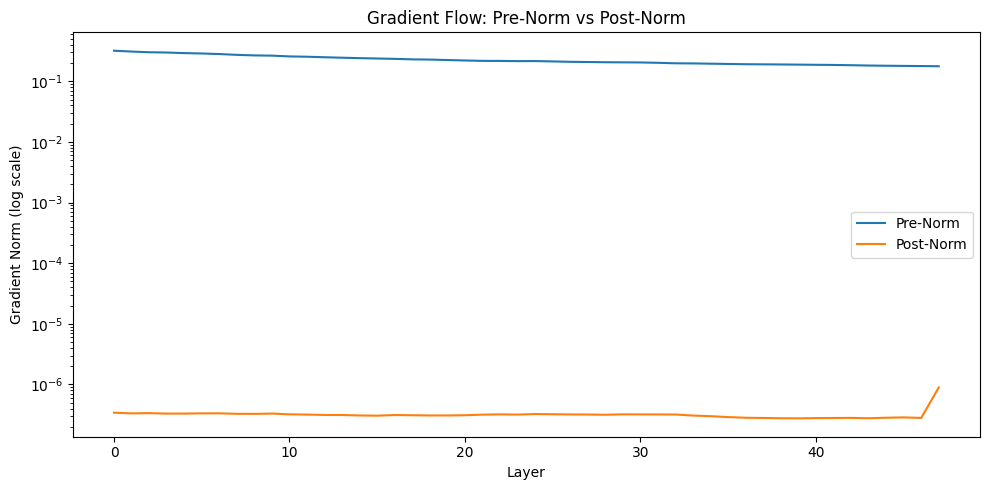

In [28]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

# ================================
# Transformer Blocks
# ================================

class PostNormBlock(nn.Module):
    # y = LN(x + F(x))
    def __init__(self, dim):
        super().__init__()
        self.ln = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
        )

    def forward(self, x):
        return self.ln(x + self.ff(x))


class PreNormBlock(nn.Module):
    # y = x + F(LN(x))
    def __init__(self, dim):
        super().__init__()
        self.ln = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
        )

    def forward(self, x):
        return x + self.ff(self.ln(x))


# ================================
# Block Stack
# ================================

class Stack(nn.Module):
    def __init__(self, block_cls, depth=48, dim=128):
        super().__init__()
        self.blocks = nn.ModuleList([block_cls(dim) for _ in range(depth)])

    def forward_with_intermediates(self, x):
        xs = []
        for block in self.blocks:
            x.retain_grad()
            xs.append(x)
            x = block(x)
        return x, xs


def measure_grad_flow(model, dim=128):
    x = torch.randn(4, dim, requires_grad=True)
    out, xs = model.forward_with_intermediates(x)
    loss = out.pow(2).mean()
    loss.backward()

    return [t.grad.norm().item() for t in xs]


# ================================
# Run the experiment
# ================================

dim = 128
depth = 48

pre_model  = Stack(PreNormBlock,  depth=depth, dim=dim)
post_model = Stack(PostNormBlock, depth=depth, dim=dim)

pre_grads  = measure_grad_flow(pre_model,  dim=dim)
post_grads = measure_grad_flow(post_model, dim=dim)

# ================================
# Plot (colors swapped by plot order)
# ================================

plt.figure(figsize=(10, 5))

# Pre-Norm SECOND → orange
plt.plot(pre_grads, label="Pre-Norm")


# Post-Norm FIRST → blue
plt.plot(post_grads, label="Post-Norm")



plt.yscale("log")
plt.xlabel("Layer")
plt.ylabel("Gradient Norm (log scale)")
plt.title("Gradient Flow: Pre-Norm vs Post-Norm")
plt.legend()
plt.tight_layout()
plt.show()

## Why Transformers Work At All — A Final Summary

Transformers only function at extreme depth because three mechanisms work together:

1. **LayerNorm stabilizes the forward pass**  
   It ensures every sublayer receives well-scaled, predictable activations, preventing variance drift and activation collapse.

2. **Residual connections stabilize the backward pass**  
   The identity path preserves gradient flow, giving every layer a strong and reliable learning signal.

3. **Pre-Norm architecture combines both into a scalable design**  
   By normalizing before each sublayer, the model keeps its computations stable *and* maintains a clean gradient highway.  
   This is why all modern LLMs (GPT, LLaMA, T5, PaLM) adopt pre-norm blocks.

**Without LayerNorm, residual connections, and the pre-norm arrangement, Transformers simply would not train at scale.**  
These components are the reason 48-, 96-, or even 200-layer models are possible today.